# Practical Lab 2: Multivariate Linear Regression, Non-Parametric Models and Cross-Validation

**Student:**
- Name: Ce Chen
- Student No: 9007166

**Dataset:** Scikit-Learn Diabetes dataset  
**Objective:** Build models to predict diabetes disease progression one year after baseline (screening tool).

> Notes for grading/readability:
> - Clear sections (Problem Framing → EDA → Cleaning → Split → Modeling → Conclusions)
> - Metrics used for regression: **R²**, **MAE**, **MAPE**
> - Train / Validation / Test split: **75% / 10% / 15%**



## 0. Setup


In [1]:

# If running in a fresh environment, uncomment the following:
# !pip -q install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor



## Helper functions (metrics & display)
We will use:
- **R²**: goodness-of-fit (higher is better)
- **MAE**: average absolute error (lower is better)
- **MAPE**: percentage error (lower is better)  
  - Note: MAPE can be unstable if true values are near zero; we add a small epsilon in the denominator.


In [2]:

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def regression_report(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE(%)": mape(y_true, y_pred),
    }

def print_report(name, rep):
    print(f"{name}")
    for k, v in rep.items():
        print(f"  {k:>8}: {v:.4f}")



# Part 1 (5 points)
## 1) Get the data
We load the diabetes dataset as a pandas DataFrame for easier EDA.


In [3]:

diab = datasets.load_diabetes(as_frame=True)
X = diab.data.copy()
y = diab.target.copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



### Dataset description (brief)
- The target is a quantitative measure of **disease progression one year after baseline**.
- Features are standardized/normalized in this dataset (many are centered/scaled).


In [4]:

print(diab.DESCR.splitlines()[0:25])


['.. _diabetes_dataset:', '', 'Diabetes dataset', '----------------', '', 'Ten baseline variables, age, sex, body mass index, average blood', 'pressure, and six blood serum measurements were obtained for each of n =', '442 diabetes patients, as well as the response of interest, a', 'quantitative measure of disease progression one year after baseline.', '', '**Data Set Characteristics:**', '', ':Number of Instances: 442', '', ':Number of Attributes: First 10 columns are numeric predictive values', '', ':Target: Column 11 is a quantitative measure of disease progression one year after baseline', '', ':Attribute Information:', '    - age     age in years', '    - sex', '    - bmi     body mass index', '    - bp      average blood pressure', '    - s1      tc, total serum cholesterol', '    - s2      ldl, low-density lipoproteins']



## 2) Frame the Problem (Problem Framing)
**Task type:** Supervised learning → **Regression** (predict a continuous target).

**Why this matters (screening tool):**
- A screening tool should identify patients likely to have higher progression risk so clinicians can prioritize follow-up and intervention.
- Model evaluation should focus on **error magnitude** and **consistency**, not just fit.

**Talking points (adapted from workshops):**
- **Performance metrics:** A single metric can be misleading; combine **R²** (fit) with **MAE/MAPE** (error). For screening, large errors on high-risk patients are especially problematic.
- **KNN intuition:** Non-parametric models (like kNN) can capture local patterns, but may be sensitive to scaling and noisy features.
- **Logistic Regression intuition:** Logistic regression is commonly used for **classification** (e.g., high-risk vs low-risk). In Part 3 we include logistic regression by converting the continuous target into a binary “high risk” label (with clear caveats).



## 3) EDA (4 points)
We include:
- Summary statistics
- Histograms
- Scatter plots (target vs selected features)
- Correlation matrix + insights


In [5]:

# Summary statistics
display(X.describe().T)

# Target stats
pd.Series(y, name="target").describe()


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.268604e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


### Histograms (features + target)


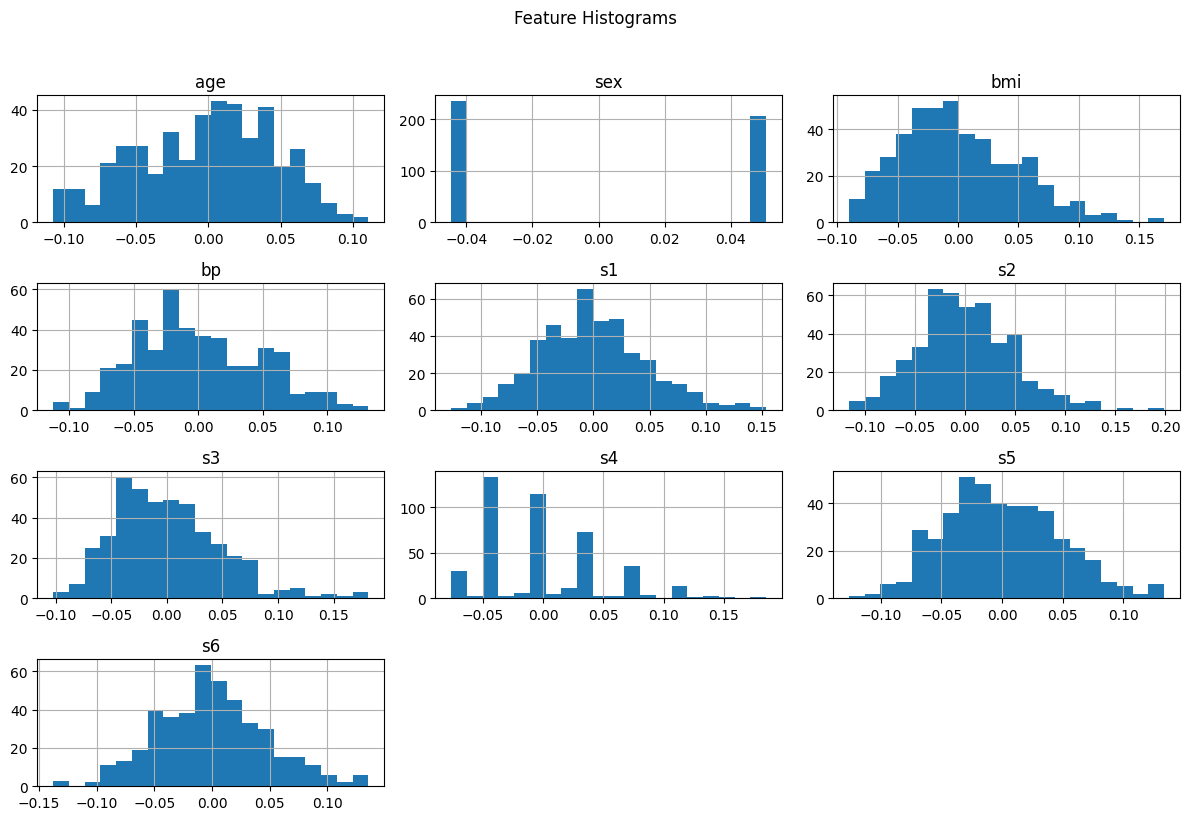

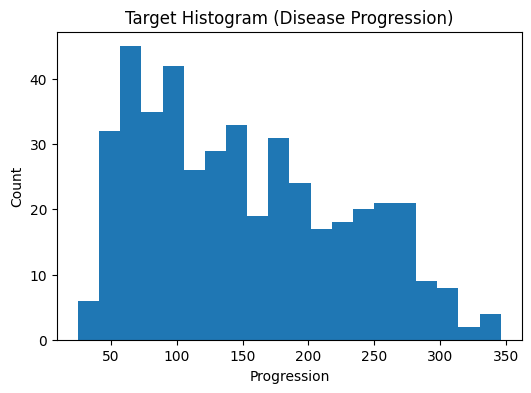

In [6]:

# Feature histograms
X.hist(bins=20, figsize=(12, 8))
plt.suptitle("Feature Histograms", y=1.02)
plt.tight_layout()
plt.show()

# Target histogram
plt.figure(figsize=(6,4))
plt.hist(y, bins=20)
plt.title("Target Histogram (Disease Progression)")
plt.xlabel("Progression")
plt.ylabel("Count")
plt.show()



### Scatter plots: target vs a few key features
We must include BMI because Part 2 focuses on BMI.


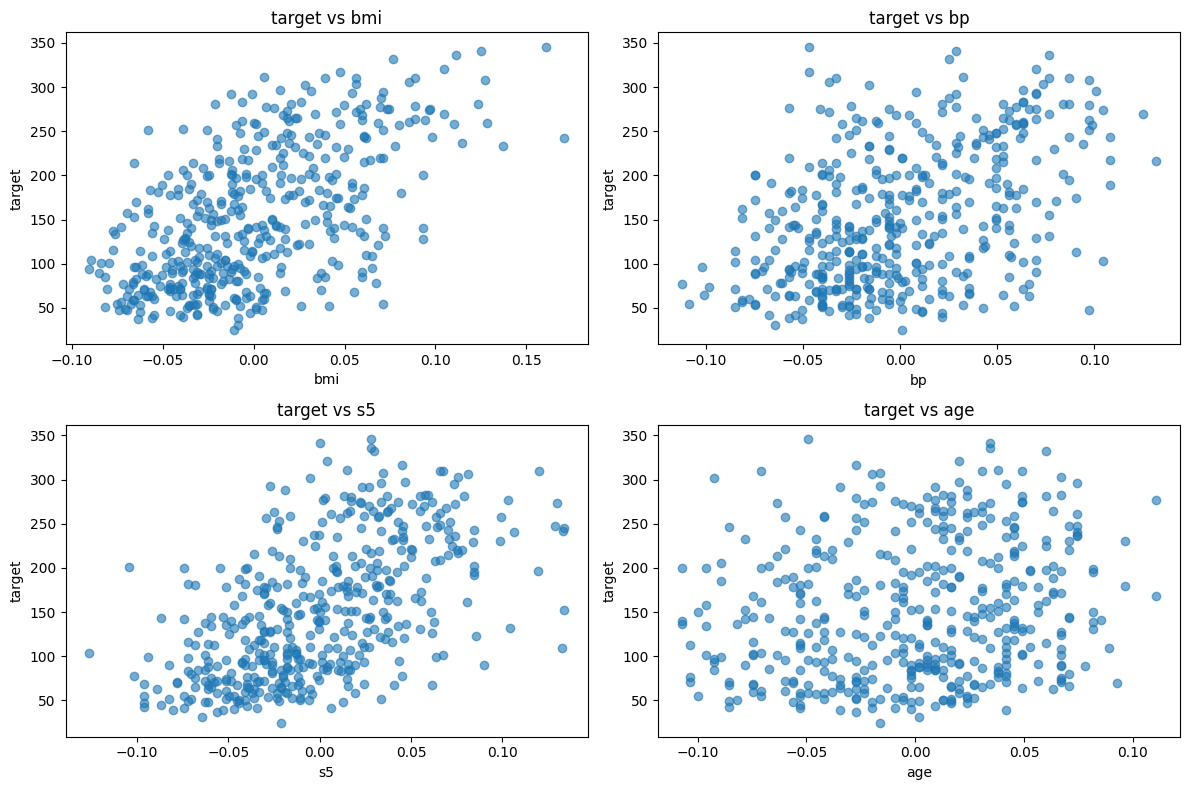

In [7]:

features_to_plot = ["bmi", "bp", "s5", "age"]
plt.figure(figsize=(12, 8))
for i, f in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    plt.scatter(X[f], y, alpha=0.6)
    plt.xlabel(f)
    plt.ylabel("target")
    plt.title(f"target vs {f}")
plt.tight_layout()
plt.show()



### Correlation matrix
We compute correlations among features and with the target.


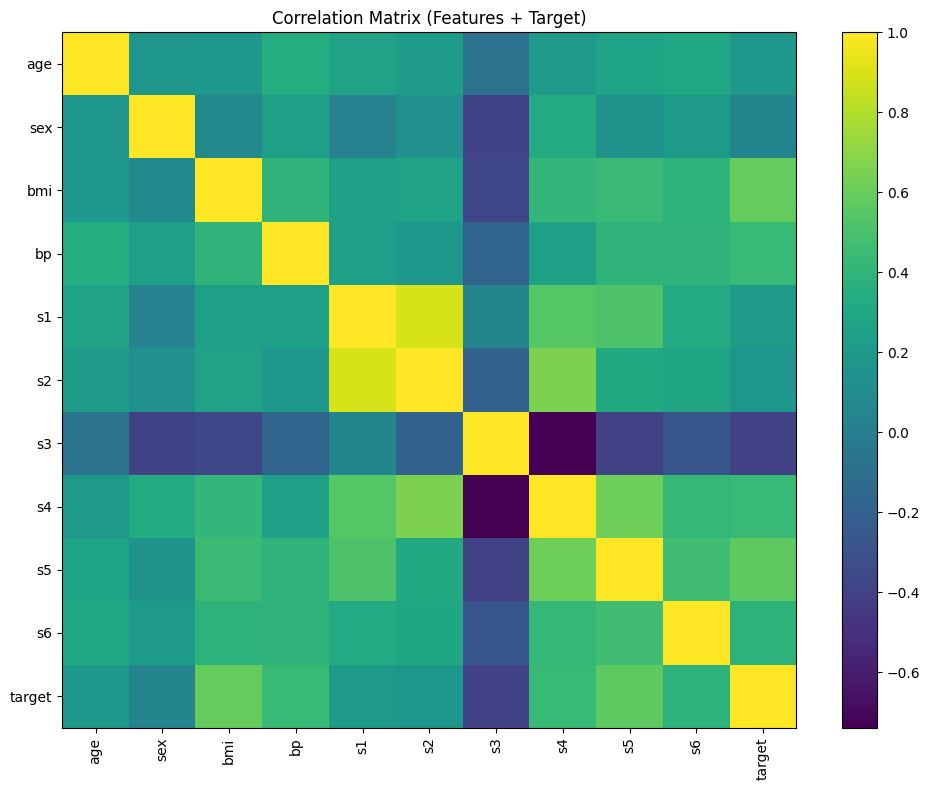

bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3    -0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64

In [8]:

df = X.copy()
df["target"] = y
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix (Features + Target)")
plt.tight_layout()
plt.show()

# Top correlations with target
corr_target = corr["target"].drop("target").sort_values(key=lambda s: np.abs(s), ascending=False)
corr_target



### Concise EDA Insights (example)
- Features such as **bmi**, **s5**, and **bp** often show stronger association with progression (see correlation with target).
- Distributions look reasonably centered (many features are standardized), but the **target is not standardized**.
- Some relationships may be non-linear (suggesting polynomial models or non-parametric models like trees/kNN could help).



## 4) Data cleaning (1 point)
The diabetes dataset is a curated toy dataset: no missing values, numeric features, consistent schema.
We still verify:
- Missing values
- Duplicate rows


In [9]:

print("Missing values per column:")
display(X.isna().sum())

print("Number of duplicate rows:", X.duplicated().sum())


Missing values per column:


age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64

Number of duplicate rows: 0



**Cleaning decision:** No cleaning required (no missing values / duplicates).  
(If you choose to do scaling for certain models, that's part of preprocessing rather than “cleaning”.)



## 5) Train / Validation / Test split (75% / 10% / 15%)
We do:
1) split out test set (15%)
2) split remaining into train (75%) and validation (10%) by proportions:
   - remaining = 85%
   - validation fraction of remaining = 10/85


In [10]:

RANDOM_STATE = 42

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

val_frac_of_trainval = 0.10 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_frac_of_trainval, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)


Train: (330, 10) (330,)
Val  : (45, 10) (45,)
Test : (67, 10) (67,)



# Part 2 (10 points)
## 6) Univariate polynomial regression using BMI (degree 0 → 5)
We build 6 models:
- degree 0: constant model (mean predictor)
- degree 1: linear regression
- degree 2..5: polynomial regression via `PolynomialFeatures` + `LinearRegression`


In [11]:

# Use BMI only (univariate)
Xtr_bmi = X_train[["bmi"]].copy()
Xva_bmi = X_val[["bmi"]].copy()
Xte_bmi = X_test[["bmi"]].copy()


In [12]:

def make_poly_model(degree: int):
    # include_bias=True creates the intercept-like feature; LinearRegression will still fit intercept by default.
    # We'll set fit_intercept=False to avoid double-counting and make parameter counting/equation clearer.
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=True)),
        ("lin", LinearRegression(fit_intercept=False))
    ])

models_uni = {deg: make_poly_model(deg) for deg in range(0, 6)}



## 7) Compare models using train + validation
We compute R², MAE, MAPE for both train and validation and summarize in a table.


In [13]:

rows = []
for deg, model in models_uni.items():
    model.fit(Xtr_bmi, y_train)
    
    pred_tr = model.predict(Xtr_bmi)
    pred_va = model.predict(Xva_bmi)
    
    rep_tr = regression_report(y_train, pred_tr)
    rep_va = regression_report(y_val, pred_va)
    
    rows.append({
        "degree": deg,
        "train_R2": rep_tr["R2"],
        "train_MAE": rep_tr["MAE"],
        "train_MAPE(%)": rep_tr["MAPE(%)"],
        "val_R2": rep_va["R2"],
        "val_MAE": rep_va["MAE"],
        "val_MAPE(%)": rep_va["MAPE(%)"],
    })

results_uni = pd.DataFrame(rows).sort_values("degree").reset_index(drop=True)
results_uni


,degree,train_R2,train_MAE,train_MAPE(%),val_R2,val_MAE,val_MAPE(%)
0,0,0.000000,66.548209,63.352070,-0.000011,63.447475,58.793283
1,1,0.354240,52.278064,48.462384,0.449292,41.997581,40.444999
2,2,0.354771,52.267273,48.447858,0.449158,41.757683,40.309938
3,3,0.355002,52.223375,48.356420,0.447291,41.741042,40.258961
4,4,0.357983,51.944372,47.963501,0.449064,41.952846,40.240642
5,5,0.358910,51.813830,47.831494,0.453513,42.083400,40.340475



## 8) Identify the best model
Primary selection criterion (typical): **highest validation R²** (tie-breaker: lower MAE / MAPE).

You can adjust the rule if your course emphasizes MAE/MAPE more for screening.


In [14]:

# Choose best by val_R2, then val_MAE (lower better), then val_MAPE (lower better)
best_row = results_uni.sort_values(
    by=["val_R2", "val_MAE", "val_MAPE(%)"],
    ascending=[False, True, True]
).iloc[0]

best_degree = int(best_row["degree"])
best_degree, best_row


(5,
 degree            5.000000
 train_R2          0.358910
 train_MAE        51.813830
 train_MAPE(%)    47.831494
 val_R2            0.453513
 val_MAE          42.083400
 val_MAPE(%)      40.340475
 Name: 5, dtype: float64)


## 9) Evaluate the chosen model on the test set (R², MAE, MAPE)


In [15]:

best_model_uni = models_uni[best_degree]
best_model_uni.fit(Xtr_bmi, y_train)

pred_te = best_model_uni.predict(Xte_bmi)
test_rep = regression_report(y_test, pred_te)
print_report(f"Best univariate polynomial model (degree={best_degree}) on TEST", test_rep)


Best univariate polynomial model (degree=5) on TEST
        R2: 0.1973
       MAE: 54.5484
   MAPE(%): 47.8845



## 10) Plot train/validation/test points + best model fit


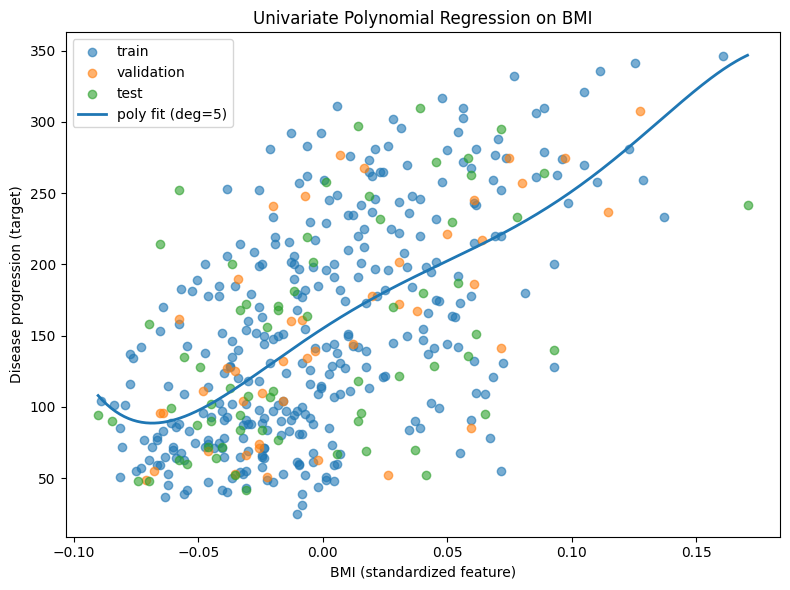

In [16]:

# Combine to plot all points, color-coded by split
plt.figure(figsize=(8,6))

plt.scatter(Xtr_bmi["bmi"], y_train, alpha=0.6, label="train")
plt.scatter(Xva_bmi["bmi"], y_val, alpha=0.6, label="validation")
plt.scatter(Xte_bmi["bmi"], y_test, alpha=0.6, label="test")

# Fit curve line
bmi_min = X["bmi"].min()
bmi_max = X["bmi"].max()
grid = np.linspace(bmi_min, bmi_max, 300).reshape(-1, 1)
grid_df = pd.DataFrame(grid, columns=["bmi"])

pred_grid = best_model_uni.predict(grid_df)
plt.plot(grid_df["bmi"], pred_grid, linewidth=2, label=f"poly fit (deg={best_degree})")

plt.title("Univariate Polynomial Regression on BMI")
plt.xlabel("BMI (standardized feature)")
plt.ylabel("Disease progression (target)")
plt.legend()
plt.tight_layout()
plt.show()



## 11) Equation of the best model (2 decimal precision)
We extract polynomial feature names and coefficients. Since we used `fit_intercept=False` and `include_bias=True`, the first term is the constant.


In [17]:

poly = best_model_uni.named_steps["poly"]
lin = best_model_uni.named_steps["lin"]

feature_names = poly.get_feature_names_out(["bmi"])
coefs = lin.coef_.reshape(-1)

eq_terms = []
for name, c in zip(feature_names, coefs):
    c2 = np.round(c, 2)
    # prettier names
    pretty = name.replace(" ", "*").replace("^", "**")
    eq_terms.append(f"({c2})*{pretty}")

equation = " + ".join(eq_terms)
print("y_hat =", equation)


y_hat = (155.08)*1 + (1131.59)*bmi + (-3946.02)*bmi**2 + (-26110.86)*bmi**3 + (768725.87)*bmi**4 + (-2823251.97)*bmi**5



## 12) Predict progression for a BMI value of your choice
Pick any BMI feature value (remember: this dataset's features are standardized).


In [18]:

bmi_value = 0.05  # you can change this
pred_value = best_model_uni.predict(pd.DataFrame({"bmi":[bmi_value]}))[0]
print(f"Predicted progression for bmi={bmi_value}: {pred_value:.2f}")


Predicted progression for bmi=0.05: 202.46



## 13) Trainable parameters for each polynomial model
For a univariate polynomial degree **d** with bias term, the number of trainable parameters is **d + 1**:
- 1 constant term
- d power terms: bmi, bmi², ..., bmi^d

We confirm using `get_feature_names_out()`.


In [19]:

param_rows = []
for deg, model in models_uni.items():
    poly = model.named_steps["poly"]
    names = poly.get_feature_names_out(["bmi"])
    param_rows.append({"degree": deg, "n_trainable_params": len(names), "feature_names": ", ".join(names)})
pd.DataFrame(param_rows)


,degree,n_trainable_params,feature_names
0,0,1,1
1,1,2,"1, bmi"
2,2,3,"1, bmi, bmi^2"
3,3,4,"1, bmi, bmi^2, bmi^3"
4,4,5,"1, bmi, bmi^2, bmi^3, bmi^4"
5,5,6,"1, bmi, bmi^2, bmi^3, bmi^4, bmi^5"



## 14) Conclusions (univariate BMI model)
Include:
- Summary of best degree and test metrics
- Where the model fails (error patterns, outliers, under/overestimation)
- Limitations (single feature, non-causal, standardized BMI, population mismatch, etc.)
- Workshop talking points: metrics tradeoffs; screening impact; local methods vs global fit; classification framing for risk thresholds.


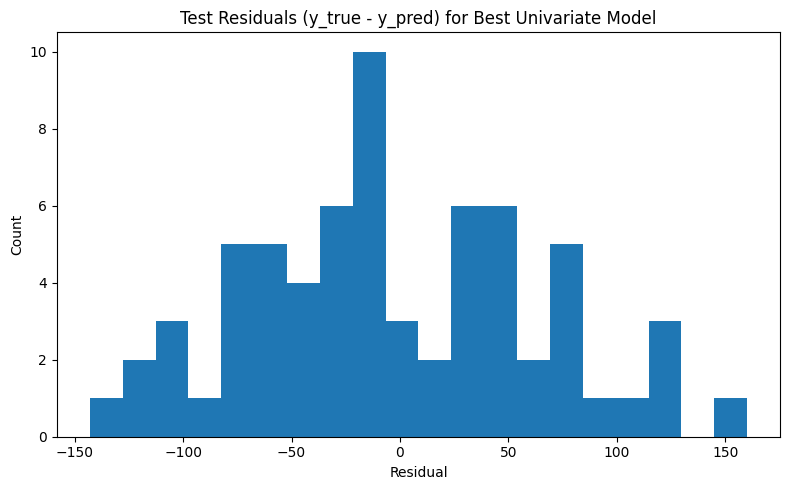

Train
        R2: 0.3589
       MAE: 51.8138
   MAPE(%): 47.8315
Validation
        R2: 0.4535
       MAE: 42.0834
   MAPE(%): 40.3405
Test
        R2: 0.1973
       MAE: 54.5484
   MAPE(%): 47.8845


In [20]:

# Residual analysis for the univariate best model
pred_tr = best_model_uni.predict(Xtr_bmi)
pred_va = best_model_uni.predict(Xva_bmi)
pred_te = best_model_uni.predict(Xte_bmi)

res_tr = y_train - pred_tr
res_va = y_val - pred_va
res_te = y_test - pred_te

plt.figure(figsize=(8,5))
plt.hist(res_te, bins=20)
plt.title("Test Residuals (y_true - y_pred) for Best Univariate Model")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print_report("Train", regression_report(y_train, pred_tr))
print_report("Validation", regression_report(y_val, pred_va))
print_report("Test", regression_report(y_test, pred_te))



**Example conclusion points (edit in your own words):**
- Best univariate polynomial degree was selected using validation performance.
- The model captures a trend between BMI and progression but **cannot explain** progression driven by other physiological factors.
- Residuals show cases where the model **underestimates high progression** or **overestimates low progression**, which matters for screening.
- Limitations: single-feature model, potential overfitting at higher degrees, and dataset is a curated benchmark (may not represent a real clinic population).



# Part 3 (5 points): Multivariate models
In this part, we use multiple features. You may drop features based on EDA, but here we start with **all features**.
We will train:
1) Two polynomial regression models (degrees > 1)
2) Two decision tree regressors (vary max_depth)
3) Two kNN regressors (vary k)
4) Two logistic regression models (classification framing)

> Important note about logistic regression:
> - The diabetes target is continuous (regression). Logistic Regression is a **classifier**.
> - To include it meaningfully, we convert the target into a binary label (e.g., high-risk vs low-risk) using a threshold (median).



## 3.1 Multivariate regression models (Polynomial, Decision Tree, kNN)
We evaluate with R², MAE, MAPE on train/validation, and then test for the chosen best model within each family.


In [21]:

# Common datasets
Xtr = X_train.copy()
Xva = X_val.copy()
Xte = X_test.copy()

# Helper to evaluate a fitted regression model
def eval_reg_model(model, Xtr, ytr, Xva, yva):
    pred_tr = model.predict(Xtr)
    pred_va = model.predict(Xva)
    rep_tr = regression_report(ytr, pred_tr)
    rep_va = regression_report(yva, pred_va)
    return rep_tr, rep_va


In [22]:

# Define candidate models
poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lin", LinearRegression())
])

poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("lin", LinearRegression())
])

tree3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
tree6 = DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE)

# kNN typically needs scaling because distances matter
knn5 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])
knn15 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=15))
])

models_multi_reg = {
    "Poly(deg=2)": poly2,
    "Poly(deg=3)": poly3,
    "Tree(max_depth=3)": tree3,
    "Tree(max_depth=6)": tree6,
    "kNN(k=5)+Scaler": knn5,
    "kNN(k=15)+Scaler": knn15,
}


In [23]:
multi_rows = []
for name, model in models_multi_reg.items():
    model.fit(Xtr, y_train)

    # Train & validation
    rep_tr, rep_va = eval_reg_model(model, Xtr, y_train, Xva, y_val)

    # Test (evaluate all models for a fair comparison)
    pred_te = model.predict(Xte)
    rep_te = regression_report(y_test, pred_te)

    multi_rows.append({
        "model": name,
        "train_R2": rep_tr["R2"],
        "train_MAE": rep_tr["MAE"],
        "train_MAPE(%)": rep_tr["MAPE(%)"],
        "val_R2": rep_va["R2"],
        "val_MAE": rep_va["MAE"],
        "val_MAPE(%)": rep_va["MAPE(%)"],
        "test_R2": rep_te["R2"],
        "test_MAE": rep_te["MAE"],
        "test_MAPE(%)": rep_te["MAPE(%)"],
    })

results_multi = pd.DataFrame(multi_rows).sort_values(
    by=["val_R2", "val_MAE", "val_MAPE(%)"],
    ascending=[False, True, True]
).reset_index(drop=True)

results_multi

,model,train_R2,train_MAE,train_MAPE(%),val_R2,val_MAE,val_MAPE(%),test_R2,test_MAE,test_MAPE(%)
0,Poly(deg=2),0.598109,39.697470,34.938567,0.602991,37.745257,41.097638,0.337028,45.867035,39.473622
1,kNN(k=15)+Scaler,0.488509,44.509293,39.289231,0.552589,40.188148,41.171253,0.410640,46.277612,42.293725
2,kNN(k=5)+Scaler,0.577666,39.886061,34.457233,0.425509,45.528889,45.998597,0.390517,45.379104,38.361057
3,Tree(max_depth=3),0.532987,43.588017,37.747793,0.412751,42.077532,43.651447,0.307655,50.371250,44.903150
4,Tree(max_depth=6),0.786947,25.998019,22.941152,0.163229,51.209721,49.783655,0.085312,54.418135,43.461149
5,Poly(deg=3),0.909413,16.332801,15.113294,-115.944928,287.181141,193.214935,-101.137393,282.704174,241.248306



### Pick the best multivariate regression model and test it


In [24]:

best_multi = results_multi.iloc[0]
best_multi_name = best_multi["model"]
best_multi_name


'Poly(deg=2)'

In [25]:

best_multi_model = models_multi_reg[best_multi_name]
best_multi_model.fit(pd.concat([Xtr, Xva]), pd.concat([y_train, y_val]))  # train on train+val for final

pred_test_multi = best_multi_model.predict(Xte)
rep_test_multi = regression_report(y_test, pred_test_multi)

print("Best multivariate regression model:", best_multi_name)
print_report("TEST", rep_test_multi)


Best multivariate regression model: Poly(deg=2)
TEST
        R2: 0.3743
       MAE: 44.7948
   MAPE(%): 37.9169



## Cross-validation
Below is an optional 5-fold CV comparison on the **training+validation** set.


In [26]:

X_cv = pd.concat([Xtr, Xva])
y_cv = pd.concat([y_train, y_val])

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "r2": "r2",
    "neg_mae": "neg_mean_absolute_error",
}

cv_rows = []
for name, model in models_multi_reg.items():
    scores = cross_validate(model, X_cv, y_cv, cv=cv, scoring=scoring, return_train_score=False)
    cv_rows.append({
        "model": name,
        "CV_R2_mean": np.mean(scores["test_r2"]),
        "CV_R2_std": np.std(scores["test_r2"]),
        "CV_MAE_mean": -np.mean(scores["test_neg_mae"]),
        "CV_MAE_std": np.std(-scores["test_neg_mae"]),
    })

pd.DataFrame(cv_rows).sort_values("CV_R2_mean", ascending=False).reset_index(drop=True)


,model,CV_R2_mean,CV_R2_std,CV_MAE_mean,CV_MAE_std
0,kNN(k=15)+Scaler,0.422715,0.055105,47.380800,1.103038
1,Poly(deg=2),0.399443,0.083262,47.733304,3.749257
2,kNN(k=5)+Scaler,0.365044,0.068229,48.636800,2.144549
3,Tree(max_depth=3),0.269768,0.085327,52.981912,2.166790
4,Tree(max_depth=6),0.130427,0.140232,57.225426,5.040339
5,Poly(deg=3),-1197.886465,1899.188725,522.053643,302.733521



## 3.2 Logistic Regression models (classification framing)
Because Logistic Regression is a **classifier**, we create a binary target:
- `1` = high risk (progression ≥ median of training target)
- `0` = low risk (progression < median)

We then train 2 logistic regression models (e.g., different C / regularization strength).
Metrics (classification):
- Accuracy
- Precision, Recall, F1
- ROC AUC (optional)


In [27]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create binary labels based on training median (threshold learned from training only)
threshold = np.median(y_train)
y_train_bin = (y_train >= threshold).astype(int)
y_val_bin   = (y_val   >= threshold).astype(int)
y_test_bin  = (y_test  >= threshold).astype(int)

threshold


np.float64(142.0)

In [28]:

def classification_report_simple(y_true, y_pred, y_proba=None):
    rep = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        try:
            rep["ROC_AUC"] = roc_auc_score(y_true, y_proba)
        except Exception:
            pass
    return rep

def print_classification(name, rep):
    print(name)
    for k, v in rep.items():
        print(f"  {k:>9}: {v:.4f}")


In [29]:

# Two logistic regression models (different C)
logreg1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE))
])

logreg2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.2, max_iter=2000, random_state=RANDOM_STATE))
])

log_models = {
    "LogReg(C=1.0)+Scaler": logreg1,
    "LogReg(C=0.2)+Scaler": logreg2,
}


In [30]:

log_rows = []
for name, model in log_models.items():
    model.fit(Xtr, y_train_bin)
    
    pred_tr = model.predict(Xtr)
    pred_va = model.predict(Xva)
    proba_va = model.predict_proba(Xva)[:, 1]
    
    rep_tr = classification_report_simple(y_train_bin, pred_tr)
    rep_va = classification_report_simple(y_val_bin, pred_va, y_proba=proba_va)
    
    log_rows.append({
        "model": name,
        "train_Acc": rep_tr["Accuracy"],
        "train_F1": rep_tr["F1"],
        "val_Acc": rep_va["Accuracy"],
        "val_F1": rep_va["F1"],
        "val_ROC_AUC": rep_va.get("ROC_AUC", np.nan),
    })

results_log = pd.DataFrame(log_rows).sort_values(by=["val_F1", "val_Acc"], ascending=False).reset_index(drop=True)
results_log


,model,train_Acc,train_F1,val_Acc,val_F1,val_ROC_AUC
0,LogReg(C=0.2)+Scaler,0.724242,0.728358,0.844444,0.844444,0.924901
1,LogReg(C=1.0)+Scaler,0.727273,0.728916,0.822222,0.826087,0.926877



### Test the best logistic regression model


In [31]:

best_log_name = results_log.iloc[0]["model"]
best_log_model = log_models[best_log_name]

# Fit on train+val (binary)
X_trva = pd.concat([Xtr, Xva])
y_trva_bin = pd.concat([y_train_bin, y_val_bin])

best_log_model.fit(X_trva, y_trva_bin)

pred_te = best_log_model.predict(Xte)
proba_te = best_log_model.predict_proba(Xte)[:, 1]

rep_te = classification_report_simple(y_test_bin, pred_te, y_proba=proba_te)
print("Best logistic regression model:", best_log_name)
print_classification("TEST", rep_te)


Best logistic regression model: LogReg(C=0.2)+Scaler
TEST
   Accuracy: 0.7164
  Precision: 0.6774
     Recall: 0.7000
         F1: 0.6885
    ROC_AUC: 0.8252


# Final Conclusions (overall)
- The task is **regression** (continuous target), so we primarily use **R²**, **MAE**, and **MAPE** to compare models.
- The univariate BMI polynomial model is simple and interpretable, but it cannot capture progression drivers beyond BMI; this typically shows up as larger errors on some patients.
- Multivariate models generally improve predictive performance by leveraging multiple clinical factors; however, they can overfit (e.g., deeper trees) and may be sensitive to preprocessing (e.g., kNN requires scaling).
- Logistic Regression is a **classification** model; here it is used only after converting the continuous target into a binary “high-risk” label for screening-style decisions. In practice, clinical use would require external validation and careful threshold selection.
